In [1]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

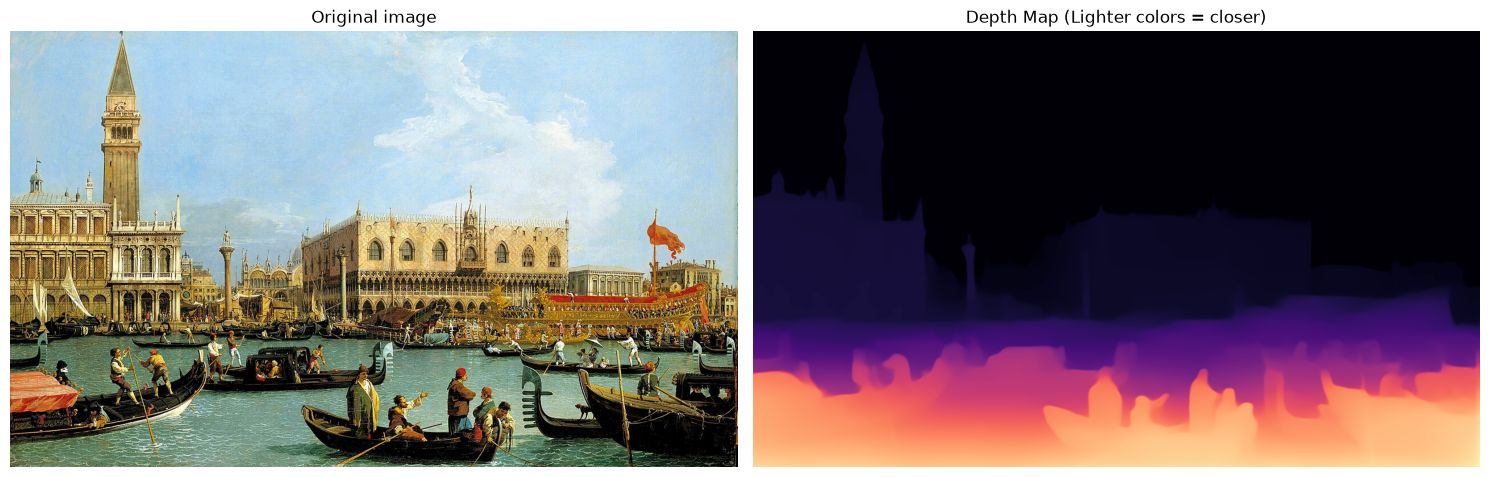

In [2]:
device_id = 0 if torch.cuda.is_available() else -1

depth_estimator = pipeline(task="depth-estimation", 
                           model="LiheYoung/depth-anything-small-hf", 
                           device=device_id)


image_path = "../data/raw_images/img_14.jpg"
image = Image.open(image_path).convert('RGB')

result = depth_estimator(image)
depth_map = result["depth"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))


axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(depth_map, cmap='magma') 
axes[1].set_title("Depth Map (Lighter colors = closer)")
axes[1].axis("off")

plt.tight_layout()